In [399]:
#Import Libraries Required for the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix,RocCurveDisplay
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

In [400]:
# Load Datasets given for the project bank-additional-full.csv and bank-full.csv

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
data = pd.read_csv(url)

data.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [401]:
#Print the first few rows present in the both datasets
data.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [402]:
#Print the first few rows present in the 2nd dataset
data.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [403]:
#print the info for both the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [404]:
#print the info output for 2nd dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [405]:
#Missing the values present in the dataset
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [406]:
#Missing the values present in the data2 set
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

/var/folders/5n/43h6x1kj4b54tkkm5t57xqq40000gn/T/ipykernel_14111/2229836909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='survived', data=data, palette='Set2')


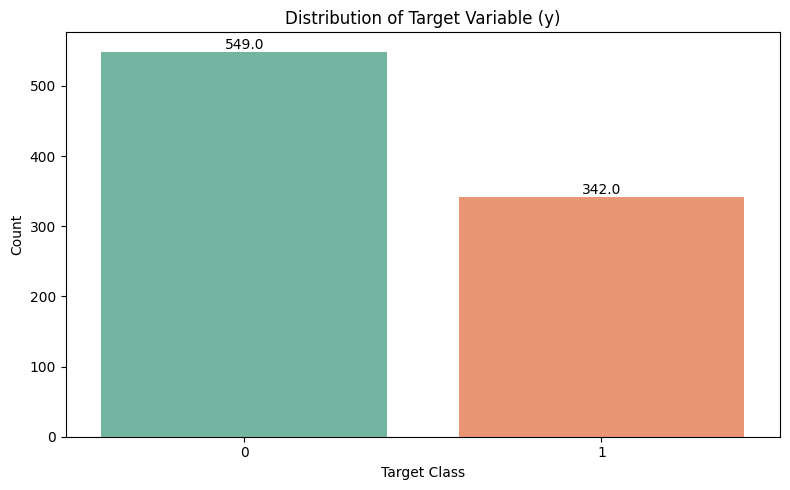

In [407]:
#check the distribution of the output variable 'y' in the dataset
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='survived', data=data, palette='Set2')

#Add count annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

/var/folders/5n/43h6x1kj4b54tkkm5t57xqq40000gn/T/ipykernel_14111/2229836909.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='survived', data=data, palette='Set2')


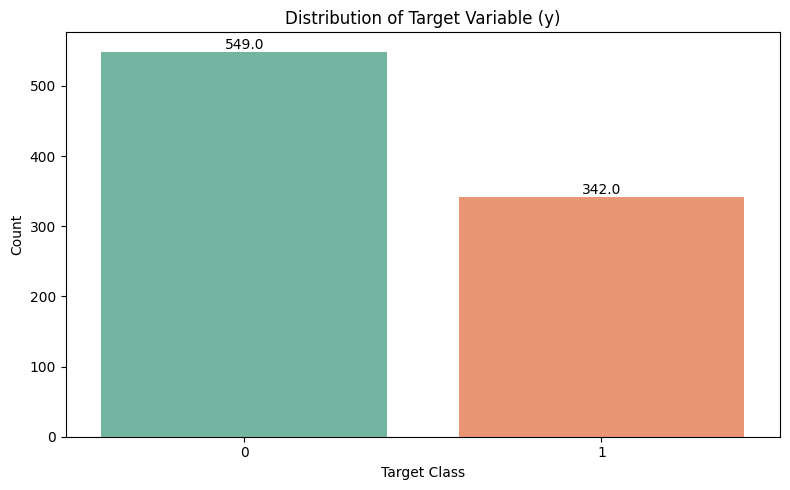

In [408]:
#check the distribution of the output variable 'y' in the dataset
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='survived', data=data, palette='Set2')

#Add count annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.title('Distribution of Target Variable (y)')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [409]:
#drop the extra columns present in the datasets to merge them for model Building
data = data.drop(columns=['emp.var.rate', 'cons.price.idx'], errors='ignore')

In [410]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [411]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [412]:
data=pd.concat([data,data])
data['survived'] = data['survived'].map({'yes': 1, 'no': 0})

data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1782 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     0 non-null      float64
 1   pclass       1782 non-null   int64  
 2   sex          1782 non-null   object 
 3   age          1428 non-null   float64
 4   sibsp        1782 non-null   int64  
 5   parch        1782 non-null   int64  
 6   fare         1782 non-null   float64
 7   embarked     1778 non-null   object 
 8   class        1782 non-null   object 
 9   who          1782 non-null   object 
 10  adult_male   1782 non-null   bool   
 11  deck         406 non-null    object 
 12  embark_town  1778 non-null   object 
 13  alive        1782 non-null   object 
 14  alone        1782 non-null   bool   
dtypes: bool(2), float64(3), int64(3), object(7)
memory usage: 198.4+ KB


In [413]:
#Check if the merged dataset doesn't have any null values present
data.isnull().sum()

survived       1782
pclass            0
sex               0
age             354
sibsp             0
parch             0
fare              0
embarked          4
class             0
who               0
adult_male        0
deck           1376
embark_town       4
alive             0
alone             0
dtype: int64

In [414]:
# Step 3: Basic Exploration
print("Dataset Shape:", data.shape)
print(data['survived'].value_counts())

Dataset Shape: (1782, 15)
Series([], Name: count, dtype: int64)


/var/folders/5n/43h6x1kj4b54tkkm5t57xqq40000gn/T/ipykernel_14111/1491923390.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='survived', data=data, palette='Set2')
/var/folders/5n/43h6x1kj4b54tkkm5t57xqq40000gn/T/ipykernel_14111/1491923390.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.countplot(x='survived', data=data, palette='Set2')


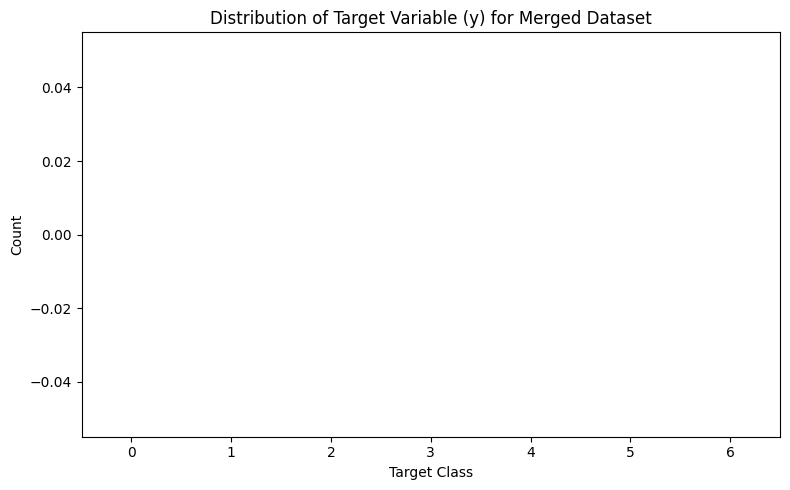

In [415]:
#Performing the Visualization Plot of the Merged Dataset
#check the distribution of the output variable 'y' in the dataset
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='survived', data=data, palette='Set2')

#Add count annotations
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')

plt.title('Distribution of Target Variable (y) for Merged Dataset')
plt.xlabel('Target Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [416]:
#Festch the categorical and also numerical values in the dataset
cat_cols=data.select_dtypes(exclude='number').columns
num_cols=data.select_dtypes(include='number').columns

In [417]:
# Showing Numeric feature distributions using for loop
for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=data)
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Histogram
    for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=data)
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
# Correlation matrix for the dataset
plt.figure(figsize=(10, 8))
sns.heatmap(data[num_cols].corr(),annot=True,fmt='.2f',cmap='coolwarm',square=True)
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

# showing visualization for Categorical feature counts using for loop
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col,data=data,)
    plt.title(f'Countplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

IndentationError: expected an indented block (2375041790.py, line 14)

In [ ]:
# 1) Split X/y from your original DataFrame `df`
X_train = data.drop('y', axis=1)
y_train = data['y']
X_test = test.drop('y', axis=1)
y_test = test['y']

Class distribution after SMOTE:
y
No     76470
Yes    76470
Name: count, dtype: int64



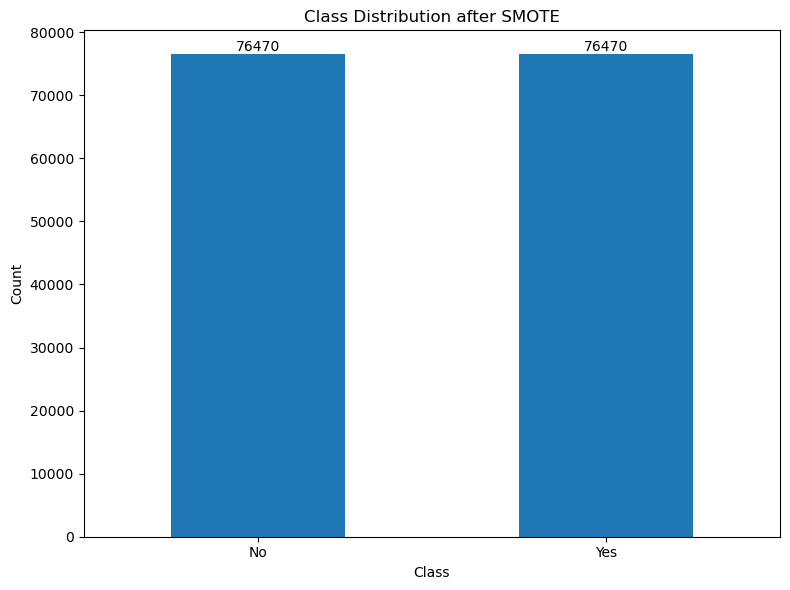

In [ ]:
# Fetch the categorical and numerical feature names
numeric_feats     = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_feats = X_train.select_dtypes(include=['object','category']).columns.tolist()

# Build the ColumnTransformer
preprocessor = ColumnTransformer([('num', StandardScaler(),numeric_feats),('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats)])

# Peform the transform your training data and testing data
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre  = preprocessor.transform(X_test)

# Balance with SMOTE to make sure there are no distribution difference
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_pre, y_train)

y_series = pd.Series(y_train_bal).map({0: 'No', 1: 'Yes'})

# counts in the desired order
counts = y_series.value_counts().reindex(['No', 'Yes'])

# Print raw counts after SMOTE
print("Class distribution after SMOTE:")
print(counts, end="\n\n")

# 5) Plot
plt.figure(figsize=(8, 6))
ax = counts.plot(kind='bar')
plt.title('Class Distribution after SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)

# 6) Annotate counts on bars
for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

In [ ]:
#Initialize the Decision Tree Model 
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(max_depth=5, random_state=42)

Decision Tree Classification Report
              precision    recall  f1-score   support

          No       0.98      0.75      0.85      7668
         Yes       0.31      0.88      0.46       972

    accuracy                           0.76      8640
   macro avg       0.64      0.81      0.65      8640
weighted avg       0.90      0.76      0.80      8640

Accuracy : 0.7635
Precision: 0.3073
Recall   : 0.8786
F1 Score : 0.4553
ROC AUC  : 0.8732


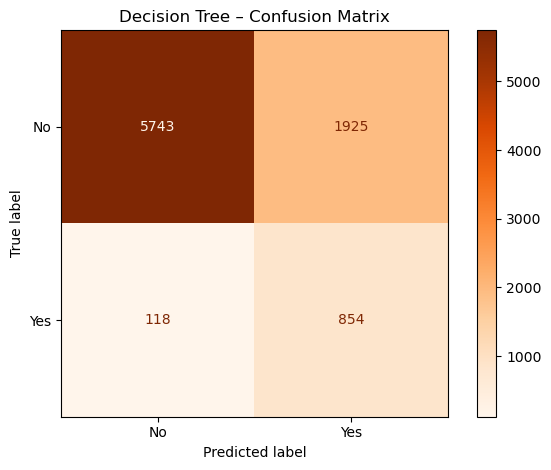

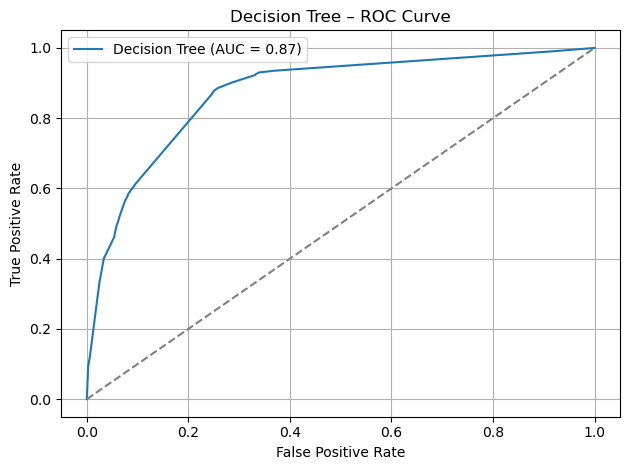

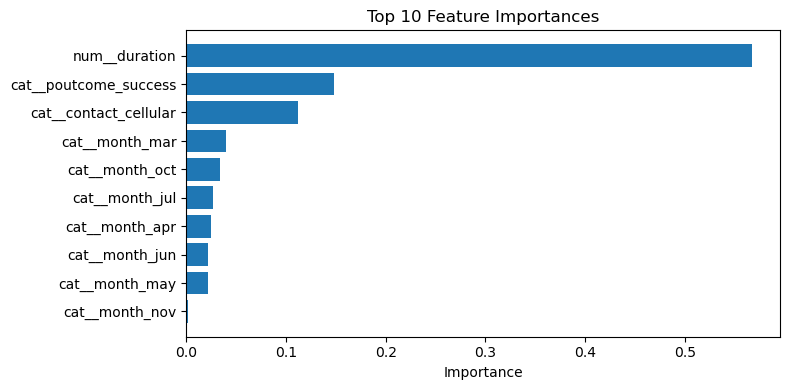

In [ ]:
#Predict the model after training
y_pred_dt   = dt_model.predict(X_test_pre)
y_proba_dt  = dt_model.predict_proba(X_test_pre)[:, 1]

# Classification report for Decision Tree Model
print("Decision Tree Classification Report")
print(classification_report(y_test, y_pred_dt, target_names=['No','Yes']))

#Evaluation metrics for the Classification Model
accuracy_dt  = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt    = recall_score(y_test, y_pred_dt)
f1_dt        = f1_score(y_test, y_pred_dt)
roc_auc_dt   = roc_auc_score(y_test, y_proba_dt)

print(f"Accuracy : {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall   : {recall_dt:.4f}")
print(f"F1 Score : {f1_dt:.4f}")
print(f"ROC AUC  : {roc_auc_dt:.4f}")

# Confusion matrix for Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=['No','Yes'])
disp.plot(cmap='Oranges')
plt.title("Decision Tree – Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC curve for the Decision Tree Model
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)
plt.figure()
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {roc_auc_dt:.2f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree – ROC Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Top-10 Feature Importances as a bar graph for representational purposes
importances   = dt_model.feature_importances_
feat_names    = preprocessor.get_feature_names_out()
idx_sorted    = np.argsort(importances)[::-1][:10]
top_feats     = feat_names[idx_sorted]
top_imports   = importances[idx_sorted]

plt.figure(figsize=(8,4))
plt.barh(np.arange(len(top_feats))[::-1], top_imports)
plt.yticks(np.arange(len(top_feats))[::-1], top_feats)
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

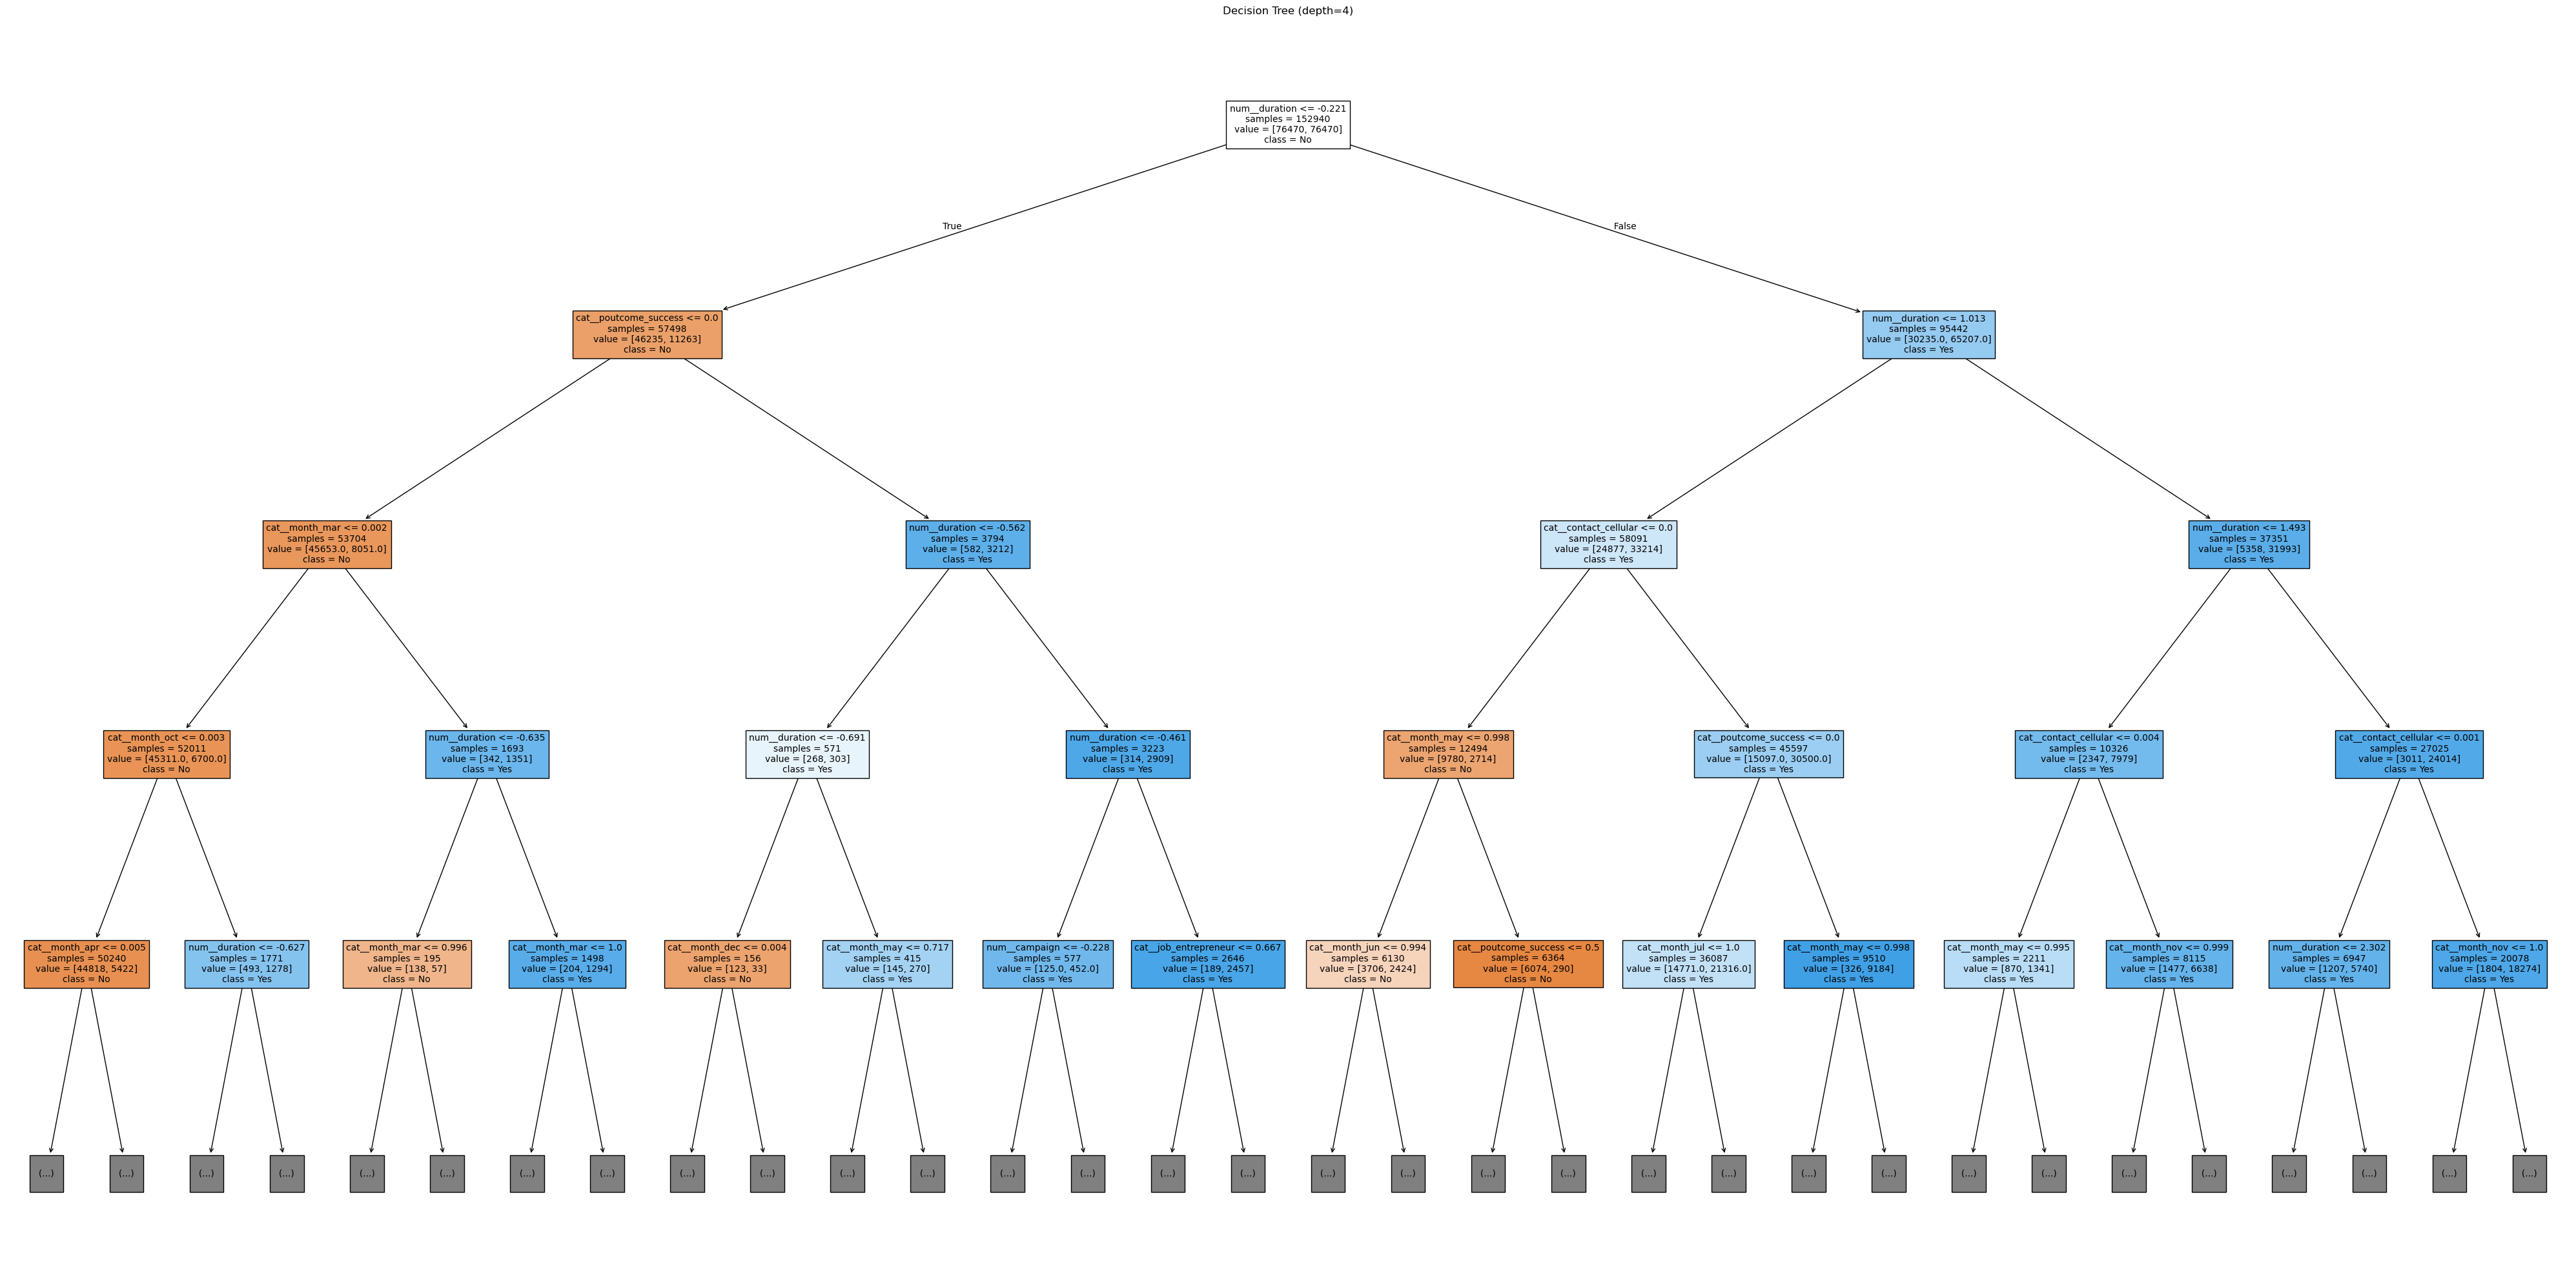

In [ ]:
# Visualize the tree structure for representation of Decision Tree Model
plt.figure(figsize=(40,20))
plot_tree(
    dt_model,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=['No','Yes'],
    filled=True,
    impurity=False,
    max_depth=4,
    fontsize=10
)
plt.title("Decision Tree (depth=4)")
plt.tight_layout()
plt.show()
